# Acquisition Modes Validation: Raw, Decimated, Accumulated

This notebook tests the three acquisition modes supported by the FIREQ backend:

| Mode | Description | Output |
|------|-------------|--------|
| **raw** | Full bandwidth ADC samples | N samples (I+Q packed) |
| **decimated** | 8x decimated + filtered | N samples (complex) |
| **accumulated** | Integrated over window | N accumulated values (complex, 32-bit I/Q) |

Each mode uses different AXI Switch routing and data parsing.

## 1. Setup

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pynq import PL

sys.path.insert(0, os.path.join(os.getcwd(), 'fireq_utils'))

from backend import FireqHardwareBackend
from backend import DMATimeoutError, TimingError, ConfigurationError
from FIREQ_LL_API.overlay_driver import FIREQ_SoC

BITSTREAM_PATH = "/home/xilinx/jupyter_notebooks/api_test_giorgio/fireq_ol/NEW_FIREQ.bit"
if not os.path.exists(BITSTREAM_PATH):
    raise FileNotFoundError(f"Bitstream not found at {BITSTREAM_PATH}!")

print("Imports successful!")

Imports successful!


In [2]:
PL.reset()
print("Loading overlay...")
overlay = FIREQ_SoC(BITSTREAM_PATH)
print("Initializing backend...")
backend = FireqHardwareBackend(overlay, debug=True)
print(f"Ready: {len(backend.hw.gens)} Gen, {len(backend.hw.acqs)} Acq")

Loading overlay...


[Backend] INFO: Initializing Backend...
[Backend] DEBUG: Step 1: Discovering hardware via HardwareInventory...
[Backend] DEBUG: HardwareInventory: Scanning overlay for IPs...
[Backend] DEBUG:   Phase 1: Discovering custom IPs...
[Backend] DEBUG:     [OK] Found 1 Signal Generator(s)
[Backend] DEBUG:     [OK] Found 2 Acquisition IP(s)
[Backend] DEBUG:     [OK] Found Trigger Generator
[Backend] DEBUG:   Phase 2: Discovering infrastructure IPs...
[Backend] DEBUG:     [OK] Found AXI DMA Controller
[Backend] DEBUG:     [OK] Found RF-DC Controller
[Backend] DEBUG:     [OK] Found AXI Switch
[Backend] DEBUG: Validating RF clocks and discovering sample rates...
[Backend] DEBUG:   Scanning DAC tiles...


Initializing backend...


[Backend] DEBUG:     [OK] DAC Tile 0: 9.585 GSPS (Lock: 2)
[Backend] DEBUG:     [SKIP] DAC Tile 1: Not active or PLL read failed (RuntimeError)
[Backend] DEBUG:     [OK] DAC Tile 2: 9.585 GSPS (Lock: 2)
[Backend] DEBUG:     [SKIP] DAC Tile 3: Not active or PLL read failed (RuntimeError)
[Backend] DEBUG:   [OK] DAC sample rate: 9.585 GSPS
[Backend] DEBUG:   Scanning ADC tiles...
[Backend] DEBUG:     [OK] ADC Tile 0: 4.792 GSPS (Lock: 2)
[Backend] DEBUG:     [SKIP] ADC Tile 1: Not active or PLL read failed (RuntimeError)
[Backend] DEBUG:     [SKIP] ADC Tile 2: Not active or PLL read failed (RuntimeError)
[Backend] DEBUG:     [SKIP] ADC Tile 3: Not active or PLL read failed (RuntimeError)
[Backend] DEBUG:   [OK] ADC sample rate: 4.792 GSPS
[Backend] INFO: Clocks Validated. DAC: 9.585 GSPS, ADC: 4.792 GSPS
[Backend] DEBUG: Hardware specs populated: DAC 9.585G, ADC 4.792G
[Backend] DEBUG: Step 2: Creating GeneratorAdapters...
[Backend] DEBUG: Step 3: Creating AcquisitionAdapters...
[Backend

Ready: 1 Gen, 2 Acq


## 2. Hardware Specs Review

Understanding the ADC characteristics is crucial for mode testing.

In [3]:
specs = backend.hw.specs

print("=== ADC Specifications ===")
print(f"  Sample Rate:        {specs['adc_sr']/1e9:.3f} GSPS")
print(f"  Nyquist Frequency:  {specs['adc_nyquist']/1e6:.1f} MHz")
print(f"  Parallelism:        {specs['adc_parallelism']} samples/cycle")
print(f"  Decimation Factor:  {specs['adc_decimation_factor']}x")
print(f"  Accumulated Width:  {specs['adc_accumulated_output_width_bits']} bits")

print("\n=== DAC Specifications ===")
print(f"  Sample Rate:        {specs['dac_sr']/1e9:.3f} GSPS")
print(f"  Nyquist Frequency:  {specs['dac_nyquist']/1e6:.1f} MHz")

=== ADC Specifications ===
  Sample Rate:        4.792 GSPS
  Nyquist Frequency:  2396.2 MHz
  Parallelism:        8 samples/cycle
  Decimation Factor:  8x
  Accumulated Width:  64 bits

=== DAC Specifications ===
  Sample Rate:        9.585 GSPS
  Nyquist Frequency:  4792.3 MHz


## 3. Helper Functions

In [4]:
def plot_acquisition(data, title="Acquisition", mode="unknown"):
    """Plot acquisition results with IQ analysis."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"{title} (mode={mode}, N={len(data)})", fontsize=14)
    
    # Time series
    axes[0, 0].plot(data.real, label='I (Real)', alpha=0.8)
    axes[0, 0].plot(data.imag, label='Q (Imag)', alpha=0.8)
    axes[0, 0].set_xlabel('Sample')
    axes[0, 0].set_ylabel('Amplitude')
    axes[0, 0].set_title('Time Domain (I/Q)')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Magnitude
    mag = np.abs(data)
    axes[0, 1].plot(mag)
    axes[0, 1].set_xlabel('Sample')
    axes[0, 1].set_ylabel('Magnitude')
    axes[0, 1].set_title(f'Magnitude (mean={mag.mean():.1f}, max={mag.max():.1f})')
    axes[0, 1].grid(True)
    
    # Phase
    phase = np.angle(data)
    axes[1, 0].plot(phase)
    axes[1, 0].set_xlabel('Sample')
    axes[1, 0].set_ylabel('Phase (rad)')
    axes[1, 0].set_title('Phase')
    axes[1, 0].grid(True)
    
    # IQ Scatter
    axes[1, 1].scatter(data.real, data.imag, s=2, alpha=0.5)
    axes[1, 1].set_xlabel('I')
    axes[1, 1].set_ylabel('Q')
    axes[1, 1].set_title('IQ Constellation')
    axes[1, 1].axis('equal')
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
def print_data_stats(data, mode):
    """Print statistics about acquired data."""
    print(f"\n=== {mode.upper()} Mode Statistics ===")
    print(f"  Shape:     {data.shape}")
    print(f"  Dtype:     {data.dtype}")
    print(f"  I range:   [{data.real.min():.1f}, {data.real.max():.1f}]")
    print(f"  Q range:   [{data.imag.min():.1f}, {data.imag.max():.1f}]")
    print(f"  Mag mean:  {np.abs(data).mean():.2f}")
    print(f"  Mag std:   {np.abs(data).std():.2f}")

## 4. DECIMATED Mode Test

Decimated mode:
- 8x decimation via FIR filter
- Lower bandwidth, filtered signal
- n_samples → n_samples complex output
- AXI Switch port: adc_index * 2 + 1

In [34]:
# Test parameters: common
N_SAMPLES = 1500
FREQ_MHZ = 3500.0
TOF = 50
T_delay = 10

In [35]:
print(">>> TEST: DECIMATED MODE")


print(f"\nConfiguration:")
print(f"  Requested samples: {N_SAMPLES}")
print(f"  Frequency: {FREQ_MHZ} MHz")

# Configure readout pulse
backend.configure_readout_pulse(
    freq=FREQ_MHZ,
    phase=0.0,
    duration_samples=N_SAMPLES ,  
    amp=0.5,
    shape='rectangular',
    target_label='Readout_Line'
)

# Run acquisition
data_dec = backend.start_experiment(
    duration_cycles=3200,
    readout_cfg={
        'target_label': 'Readout_Line',
        'num_samples': N_SAMPLES,
        'freq': FREQ_MHZ,
        'mode': 'decimated',
        'trigger_delay': TOF,
        'time_of_flight': T_delay
    }
)

print(f"\n[SUCCESS] Got {len(data_dec)} samples")
print_data_stats(data_dec, 'decimated')

[Backend] DEBUG: Readout: 3500.0MHz, 1500smp
[Backend] DEBUG: Timing validated: dur=3200, delay=50, tof=10, acq=3000
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=3200, Shots=1
[Backend] INFO: Acquired: (1500,) samples


>>> TEST: DECIMATED MODE

Configuration:
  Requested samples: 1500
  Frequency: 3500.0 MHz

[SUCCESS] Got 1500 samples

=== DECIMATED Mode Statistics ===
  Shape:     (1500,)
  Dtype:     complex128
  I range:   [-57.0, 2428.0]
  Q range:   [-1641.0, 109.0]
  Mag mean:  182.06
  Mag std:   685.96


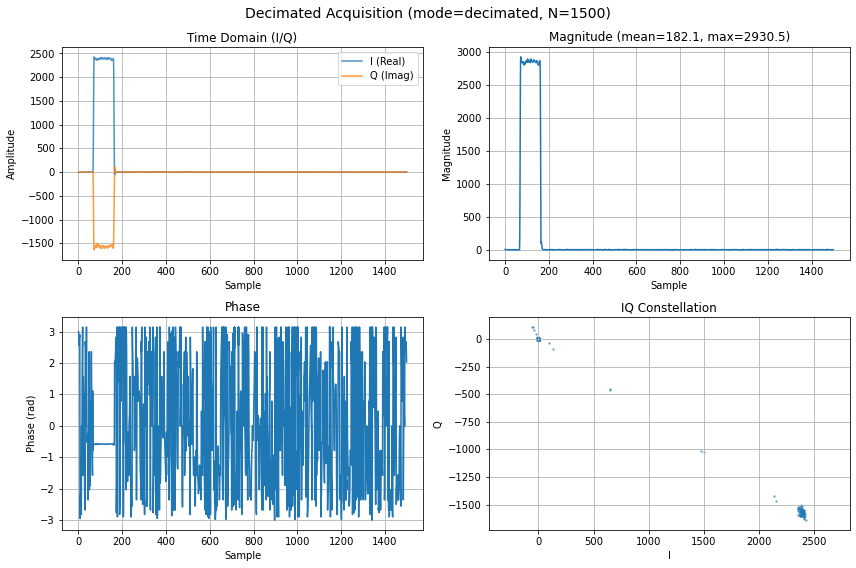

In [36]:
plot_acquisition(data_dec, "Decimated Acquisition", "decimated")

## 5. RAW Mode Test

Raw mode:
- Full ADC bandwidth (no decimation)
- n_samples must be multiple of adc_parallelism (8)
- Captures full-rate IQ data
- AXI Switch port: adc_index * 2 + 0

In [133]:
print(">>> TEST: RAW MODE")

# Raw mode requires samples to be multiple of parallelism
ADC_PARALLELISM = backend.hw.specs['adc_parallelism']


print(f"\nConfiguration:")
print(f"  Requested samples: {N_SAMPLES_RAW}")
print(f"  ADC Parallelism: {ADC_PARALLELISM}")
print(f"  Cycles needed: {N_SAMPLES_RAW // ADC_PARALLELISM}")

# Run raw acquisition
data_raw = backend.start_experiment(
    duration_cycles=2000,
    readout_cfg={
        'target_label': 'Readout_Line',
        'num_samples': N_SAMPLES,
        'freq': FREQ_MHZ,
        'mode': 'raw',
        'trigger_delay': T_delay,
        'time_of_flight': TOF
    }
)

print(f"\n[SUCCESS] Got {len(data_raw)} samples")
print_data_stats(data_raw, 'raw')

[Backend] DEBUG: Timing validated: dur=2000, delay=10, tof=50, acq=374
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=2000, Shots=1
[Backend] INFO: Acquired: (1500,) samples


>>> TEST: RAW MODE

Configuration:
  Requested samples: 500
  ADC Parallelism: 8
  Cycles needed: 62

[SUCCESS] Got 1500 samples

=== RAW Mode Statistics ===
  Shape:     (1500,)
  Dtype:     int16
  I range:   [-13.0, 308.0]
  Q range:   [0.0, 0.0]
  Mag mean:  18.50
  Mag std:   70.32


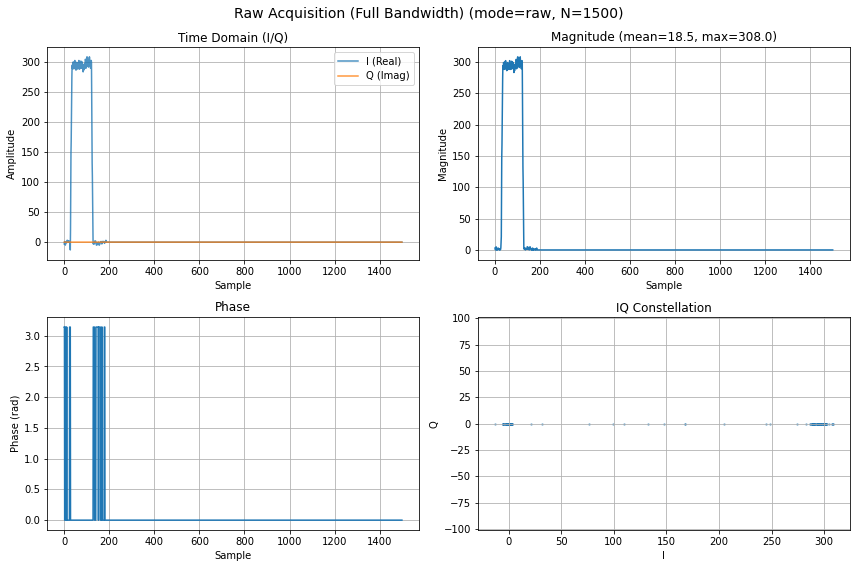

In [134]:
plot_acquisition(data_raw, "Raw Acquisition (Full Bandwidth)", "raw")

## 6. ACCUMULATED Mode Test

Accumulated mode:
- Integrates IQ samples over acquisition window
- Returns 64-bit accumulated values (32-bit I, 32-bit Q)
- Same AXI Switch port as decimated (adc_index * 2 + 1)
- Useful for resonator spectroscopy

In [135]:
print(">>> TEST: ACCUMULATED MODE")

# Accumulated mode - returns integrated values
# n_samples here represents the number of accumulated outputs (each 64-bit)
N_SAMPLES_ACC = 100

print(f"\nConfiguration:")
print(f"  Requested accumulated samples: {N_SAMPLES_ACC}")
print(f"  Output width: {backend.hw.specs['adc_accumulated_output_width_bits']} bits")

# Run accumulated acquisition
data_acc = backend.start_experiment(
    duration_cycles=2000,
    readout_cfg={
        'target_label': 'Readout_Line',
        'num_samples': N_SAMPLES_ACC,
        'freq': FREQ_MHZ,
        'mode': 'accumulated',
        'trigger_delay': 50,
        'time_of_flight': 50
    }
)

print(f"\n[SUCCESS] Got {len(data_acc)} accumulated values")
print_data_stats(data_acc, 'accumulated')

[Backend] DEBUG: Timing validated: dur=2000, delay=50, tof=50, acq=200
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=2000, Shots=1
[Backend] INFO: Acquired: (100,) samples


>>> TEST: ACCUMULATED MODE

Configuration:
  Requested accumulated samples: 100
  Output width: 64 bits

[SUCCESS] Got 100 accumulated values

=== ACCUMULATED Mode Statistics ===
  Shape:     (100,)
  Dtype:     complex128
  I range:   [0.0, 1971006.0]
  Q range:   [0.0, 167975.0]
  Mag mean:  19781.51
  Mag std:   196823.51


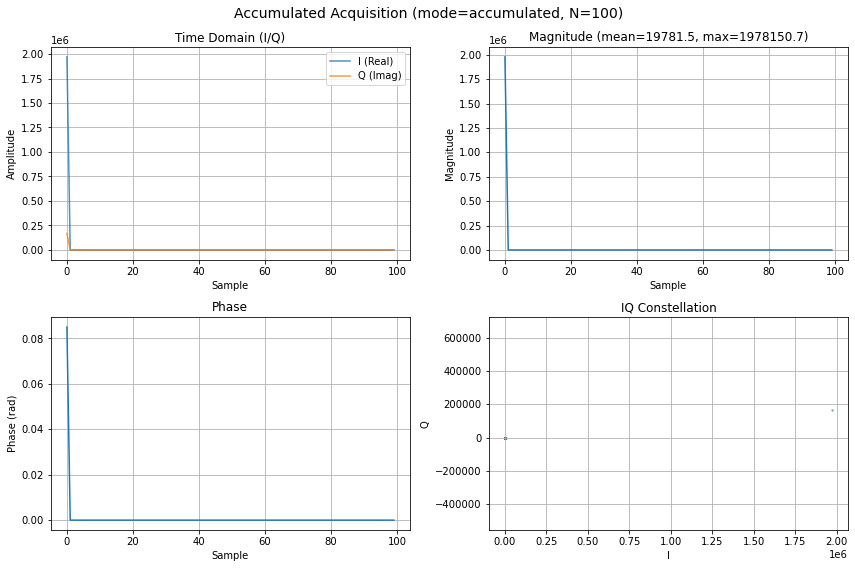

In [136]:
plot_acquisition(data_acc, "Accumulated Acquisition", "accumulated")

## 7. Mode Comparison

Compare all three modes side-by-side.

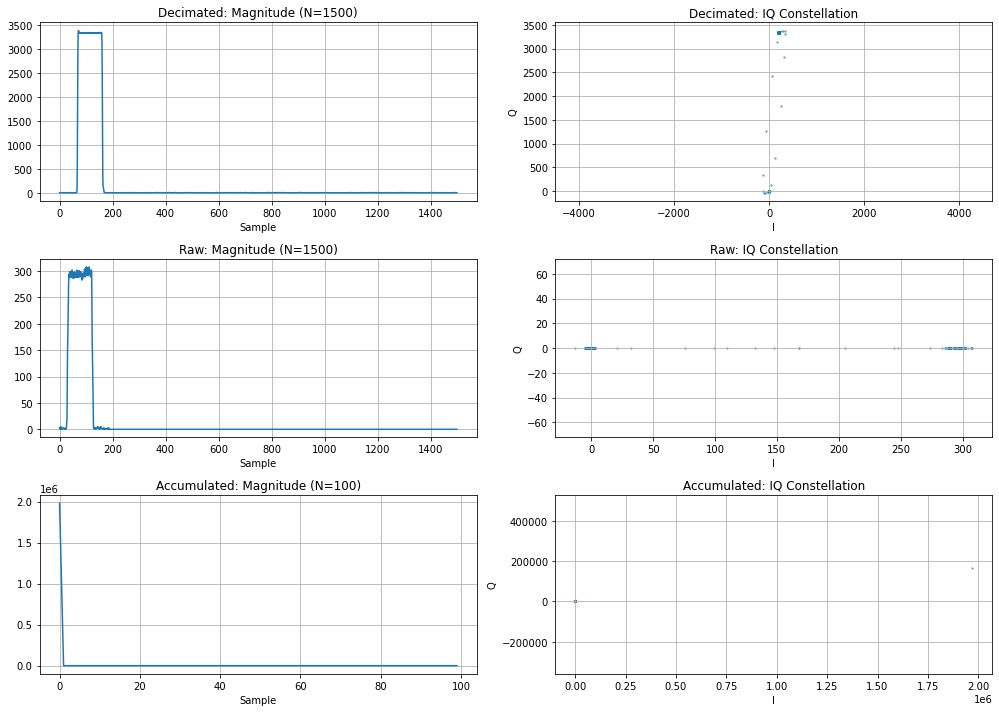

In [137]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

modes_data = [
    ('Decimated', data_dec),
    ('Raw', data_raw),
    ('Accumulated', data_acc)
]

for i, (name, data) in enumerate(modes_data):
    # Time domain
    axes[i, 0].plot(np.abs(data))
    axes[i, 0].set_title(f'{name}: Magnitude (N={len(data)})')
    axes[i, 0].set_xlabel('Sample')
    axes[i, 0].grid(True)
    
    # IQ scatter
    axes[i, 1].scatter(data.real, data.imag, s=2, alpha=0.5)
    axes[i, 1].set_title(f'{name}: IQ Constellation')
    axes[i, 1].set_xlabel('I')
    axes[i, 1].set_ylabel('Q')
    axes[i, 1].axis('equal')
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()

In [138]:
print("\n" + "="*60)
print("MODE COMPARISON SUMMARY")
print("="*60)
print(f"{'Mode':<15} {'Samples':<10} {'Mag Mean':<12} {'Mag Std':<12} {'Dtype'}")
print("-"*60)

for name, data in modes_data:
    mag_mean = np.abs(data).mean()
    mag_std = np.abs(data).std()
    print(f"{name:<15} {len(data):<10} {mag_mean:<12.2f} {mag_std:<12.2f} {data.dtype}")

print("="*60)


MODE COMPARISON SUMMARY
Mode            Samples    Mag Mean     Mag Std      Dtype
------------------------------------------------------------
Decimated       1500       212.52       803.79       complex128
Raw             1500       18.50        70.32        int16
Accumulated     100        19781.51     196823.51    complex128


## 8. Robustness Tests

Test edge cases and verify error handling.

In [139]:
print(">>> EDGE CASE TESTS")

# Test 1: Minimum samples (decimated)
print("\n--- Test: Minimum samples (decimated) ---")
try:
    data = backend.start_experiment(
        duration_cycles=500,
        readout_cfg={
            'target_label': 'Readout_Line',
            'num_samples': 16,  # Very small
            'freq': 200.0,
            'mode': 'decimated'
        }
    )
    print(f"  [OK] Got {len(data)} samples")
except Exception as e:
    print(f"  [FAIL] {type(e).__name__}: {e}")

# Test 2: Raw with non-aligned samples (should work, DMA handles it)
print("\n--- Test: Raw mode alignment ---")
try:
    data = backend.start_experiment(
        duration_cycles=1000,
        readout_cfg={
            'target_label': 'Readout_Line',
            'num_samples': 64,  # Multiple of 8
            'freq': 200.0,
            'mode': 'raw'
        }
    )
    print(f"  [OK] Got {len(data)} samples")
except Exception as e:
    print(f"  [FAIL] {type(e).__name__}: {e}")

# Test 3: Large accumulated acquisition
print("\n--- Test: Large accumulated ---")
try:
    data = backend.start_experiment(
        duration_cycles=5000,
        readout_cfg={
            'target_label': 'Readout_Line',
            'num_samples': 1000,
            'freq': 200.0,
            'mode': 'accumulated'
        }
    )
    print(f"  [OK] Got {len(data)} accumulated values")
except Exception as e:
    print(f"  [FAIL] {type(e).__name__}: {e}")

# Test 4: Invalid mode (should raise error)
print("\n--- Test: Invalid mode (should fail) ---")
try:
    data = backend.start_experiment(
        duration_cycles=1000,
        readout_cfg={
            'target_label': 'Readout_Line',
            'num_samples': 100,
            'freq': 200.0,
            'mode': 'invalid_mode'  # Should fail
        }
    )
    print("  [UNEXPECTED] Should have raised error!")
except ValueError as e:
    print(f"  [EXPECTED] ValueError: {e}")
except Exception as e:
    print(f"  [OK] Error caught: {type(e).__name__}")

[Backend] DEBUG: Timing validated: dur=500, delay=50, tof=1, acq=32
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=500, Shots=1
[Backend] INFO: Acquired: (16,) samples
[Backend] DEBUG: Timing validated: dur=1000, delay=50, tof=1, acq=16
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=1000, Shots=1
[Backend] INFO: Acquired: (64,) samples
[Backend] DEBUG: Timing validated: dur=5000, delay=50, tof=1, acq=2000
[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=5000, Shots=1
[Backend] INFO: Acquired: (1000,) samples
[Backend] DEBUG: Timing validated: dur=1000, delay=50, tof=1, acq=200


>>> EDGE CASE TESTS

--- Test: Minimum samples (decimated) ---
  [OK] Got 16 samples

--- Test: Raw mode alignment ---
  [OK] Got 64 samples

--- Test: Large accumulated ---
  [OK] Got 1000 accumulated values

--- Test: Invalid mode (should fail) ---
error, input value for type is not recognized, allowed values are 'decimated' and 'accumulated'
  [OK] Error caught: DriverError


## 9. Multi-ADC Test (if available)

Test acquisition from different ADC indices.

In [41]:
print(">>> MULTI-ADC TEST")

n_acqs = len(backend.hw.acqs)
print(f"Available ADCs: {n_acqs}")

for adc_idx in range(n_acqs):
    print(f"\n--- ADC {adc_idx} ---")
    try:
        data = backend.start_experiment(
            duration_cycles=1500,
            readout_cfg={
                'adc_index': adc_idx,
                'gen_index': 0,
                'trigger_channel': 1,
                'num_samples': 128,
                'freq': 200.0,
                'mode': 'decimated'
            }
        )
        print(f"  [OK] ADC {adc_idx}: {len(data)} samples, mag_mean={np.abs(data).mean():.2f}")
    except Exception as e:
        print(f"  [FAIL] ADC {adc_idx}: {type(e).__name__}: {e}")

[Backend] DEBUG: Timing validated: dur=1500, delay=50, tof=1, acq=256
[Backend] INFO: Armed: 'Physical[Gen0->ADC0]' [Gen0->ADC0] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=1500, Shots=1
[Backend] INFO: Acquired: (128,) samples
[Backend] DEBUG: Timing validated: dur=1500, delay=50, tof=1, acq=256
[Backend] INFO: Armed: 'Physical[Gen0->ADC1]' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=1500, Shots=1
[Backend] INFO: Acquired: (128,) samples


>>> MULTI-ADC TEST
Available ADCs: 2

--- ADC 0 ---
  [OK] ADC 0: 128 samples, mag_mean=2.93

--- ADC 1 ---
  [OK] ADC 1: 128 samples, mag_mean=2559.13


## 10. Conclusion

In [42]:
print("\n" + "="*60)
print("ACQUISITION MODES TEST COMPLETE")
print("="*60)

print("\nModes tested:")
print("  ✓ Decimated: 8x FIR filtered acquisition")
print("  ✓ Raw: Full bandwidth ADC capture")
print("  ✓ Accumulated: Integrated IQ values")

print("\nKey observations:")
print(f"  - Decimated output: {len(data_dec)} samples")
print(f"  - Raw output: {len(data_raw)} samples")
print(f"  - Accumulated output: {len(data_acc)} values")

health = backend.check_hardware_health()
print(f"\nFinal hardware state: DMA={health['dma']}, Clocks={health['clocks']}")


ACQUISITION MODES TEST COMPLETE

Modes tested:
  ✓ Decimated: 8x FIR filtered acquisition
  ✓ Raw: Full bandwidth ADC capture
  ✓ Accumulated: Integrated IQ values

Key observations:
  - Decimated output: 1500 samples
  - Raw output: 1500 samples
  - Accumulated output: 100 values

Final hardware state: DMA=idle, Clocks=ok
